In [5]:
import ldpc.codes as codes
from ldpc import BpOsdDecoder, UnionFindDecoder, BpDecoder
import numpy as np
import pymatching as pm

# create the LDPC code we want to use 
# use ldpc package 
H = codes.rep_code(5)

# use QUITS


print(H)

<Compressed Sparse Row sparse matrix of dtype 'uint8'
	with 8 stored elements and shape (4, 5)>
  Coords	Values
  (0, 0)	1
  (0, 1)	1
  (1, 1)	1
  (1, 2)	1
  (2, 2)	1
  (2, 3)	1
  (3, 3)	1
  (3, 4)	1


In [ ]:
# decode on H with BpOSDecoder
bp_osd = BpOsdDecoder(
            H,
            error_rate =0.1, #dummy error rates
            bp_method = 'product_sum',
            max_iter = 7,
            schedule = 'serial',
            osd_method = 'osd_cs', #set to OSD_0 for fast solve
            osd_order = 2
        )

syndrome = np.random.randint(size=H.shape[0], low=0, high=2).astype(np.uint8)

print(f"Syndrome: {syndrome}")
decoding = bp_osd.decode(syndrome)
print(f"Decoding: {decoding}")
decoding_syndrome = H@decoding % 2
print(f"Decoding syndrome: {decoding_syndrome}")

TypeError: Argument 'value' has incorrect type (expected float, got numpy.ndarray)

In [52]:
# get soft info from BP decoder
p_err = 0.9
bp = BpDecoder(
            H,
            # error_rate=0.6,
            error_channel= p_err*np.ones(H.shape[1]),
            bp_method = 'product_sum',
            max_iter = 7,
            schedule = 'serial',
)

syndrome = np.random.randint(size=H.shape[0], low=0, high=2).astype(np.uint8)

print(f"Error channel: {p_err}")
print(f"Syndrome: {syndrome}")
decoding = bp.decode(syndrome)
print(f"Decoding: {decoding}")
decoding_syndrome = H@decoding % 2
print(f"Decoding syndrome: {decoding_syndrome}")
llrs = bp.log_prob_ratios
print(f"LLRS: {llrs}")


"""
Outputs to puzzle over:

Error channel: 0.6
Syndrome: [0 0 1 0]
Decoding: [1 1 1 0 0]
Decoding syndrome: [0 0 1 0]
LLRS: [-0.81093022 -1.21639532 -0.81093022  0.40546511  0.40546511]


Error channel: 0.1
Syndrome: [0 0 1 1]
Decoding: [0 0 0 1 0]
Decoding syndrome: [0 0 1 1]
LLRS: [ 4.39444915  6.59167373  4.39444915 -6.59167373  6.59167373]


Error channel: 0.5
Syndrome: [1 0 0 0]
Decoding: [1 1 1 1 1]
Decoding syndrome: [0 0 0 0]
LLRS: [0. 0. 0. 0. 0.]

"""

Error channel: 0.9
Syndrome: [0 1 1 0]
Decoding: [1 1 0 1 1]
Decoding syndrome: [0 1 1 0]
LLRS: [-4.39444915 -2.19722458  4.39444915 -6.59167373 -6.59167373]


'\nOutputs to puzzle over:\n\nError channel: 0.6\nSyndrome: [0 0 1 0]\nDecoding: [1 1 1 0 0]\nDecoding syndrome: [0 0 1 0]\nLLRS: [-0.81093022 -1.21639532 -0.81093022  0.40546511  0.40546511]\n\n\nError channel: 0.1\nSyndrome: [0 0 1 1]\nDecoding: [0 0 0 1 0]\nDecoding syndrome: [0 0 1 1]\nLLRS: [ 4.39444915  6.59167373  4.39444915 -6.59167373  6.59167373]\n\n\nError channel: 0.5\nSyndrome: [1 0 0 0]\nDecoding: [1 1 1 1 1]\nDecoding syndrome: [0 0 0 0]\nLLRS: [0. 0. 0. 0. 0.]\n\n'

In [ ]:
# decode on H with UF decoder


In [ ]:
# decode on H with soft info decoder

### Use BP LLRs to Reweight MWPM

In [54]:
from quits.qldpc_code import HgpCode

# create surface code to use 

d = 5

def get_parity_toric(d):
    H_rep = codes.rep_code(d).toarray().astype(int)

    # build cyclic row
    cyclic_row = np.zeros((1, d), dtype=int)
    cyclic_row[0, 0] = 1
    cyclic_row[0, -1] = 1

    # append it
    H_rep_cyclic = np.vstack([H_rep, cyclic_row])

    code = HgpCode(H_rep_cyclic, H_rep_cyclic) # generate a toric code from the repetition code

    return code.hx, code.hz, code.lx, code.lz

Hx,Hz,Lx,Lz = get_parity_toric(d)

In [111]:
# now we can make the BP decoder for the surface code and get soft info from it. Pick one of the two parity check matrices to decode on, and get the soft info from that decoder.



p = 0.1
bp = BpDecoder(
            Hx,
            error_rate=p,
            # error_channel= p*np.ones(H.shape[1]),
            bp_method = 'product_sum',
            max_iter = 7,
            schedule = 'serial',
)
noise = np.random.binomial(1,p,Hx.shape[1])
syndrome = Hx@noise % 2

print(f"Error channel probability: {p}")
print(f"Syndrome: {syndrome}")
decoding = bp.decode(syndrome)
print(f"Decoding: {decoding}")
decoding_syndrome = Hx@decoding % 2
print(f"Decoding syndrome: {decoding_syndrome}")
llrs = bp.log_prob_ratios
print(f"LLRS: {llrs}")

Error channel probability: 0.1
Syndrome: [0 1 1 0 1 0 0 1 0]
Decoding: [0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]
Decoding syndrome: [0 1 1 0 1 0 0 1 0]
LLRS: [ 2.29196978  2.51438997 -1.23911332  4.23034508  3.77978496  2.49446365
  3.90736459  3.74818652  2.32480433  3.97102097  1.93836618  2.55965829
  4.72347586 -1.09893817  3.34795019  3.93456501  2.0479739   2.47694112]


In [99]:
from pymatching import Matching

matching = Matching(Hx)

# first decode the syndrome with standard MWPM decoder to get a baseline for performance
correction_MWPM = matching.decode(syndrome)
print(f"MWPM correction: {correction_MWPM}")
predicted_flip = Lx@correction_MWPM % 2
print(f"Predicted flip: {predicted_flip}") # this is length 2, it should be length 1. Maybe this is because I started with repitition code ?  I thought I added BCs but whatever
actual_flip = Lx@noise % 2
print(f"Actual flip: {actual_flip}")
error = not np.array_equal(predicted_flip, actual_flip)
print(f"MWPM error: {error}")

print(matching.edges())

MWPM correction: [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 1 1 0]
Predicted flip: [0 0]
Actual flip: [0 0]
MWPM error: False
[(0, 4, {'fault_ids': {0}, 'weight': 1.0, 'error_probability': -1.0}), (0, 1, {'fault_ids': {1}, 'weight': 1.0, 'error_probability': -1.0}), (1, 2, {'fault_ids': {2}, 'weight': 1.0, 'error_probability': -1.0}), (2, 3, {'fault_ids': {3}, 'weight': 1.0, 'error_probability': -1.0}), (3, 4, {'fault_ids': {4}, 'weight': 1.0, 'error_probability': -1.0}), (5, 9, {'fault_ids': {5}, 'weight': 1.0, 'error_probability': -1.0}), (5, 6, {'fault_ids': {6}, 'weight': 1.0, 'error_probability': -1.0}), (6, 7, {'fault_ids': {7}, 'weight': 1.0, 'error_probability': -1.0}), (7, 8, {'fault_ids': {8}, 'weight': 1.0, 'error_probability': -1.0}), (8, 9, {'fault_ids': {9}, 'weight': 1.0, 'error_probability': -1.0}), (10, 14, {'fault_ids': {10}, 'weight': 1.0, 'error_probability': -1.0}), (10, 11, {'fault_ids': {11}, 'weight': 1.0, 'er

In [ ]:
# now we can use our LLRs to do a reweighting of MWPM
# set the minimum weight to be 0 to avoid issues with negative weights

def get_belief_matching(matching, llrs):
    edges = matching.edges()
    belief_match = Matching()
    for (u,v,data), llr in zip(edges, llrs):
        weight = max(0,llr) # set minimum weight to 0
        fault_id = data['fault_ids']
        if None in (u,v): # if one of the nodes is None, it's a boundary edge
            belief_match.add_boundary_edge(u if u is not None else v, weight=weight, fault_ids=fault_id)
        else:
            belief_match.add_edge(u,v, weight=weight, fault_ids=fault_id)
    return belief_match

belief_match = get_belief_matching(matching, llrs)
print(f"Belief MWPM edges: {belief_match.edges()}")

{0}
{1}
{2}
{3}
{4}
{5}
{6}
{7}
{8}
{9}
{10}
{11}
{12}
{13}
{14}
{15}
{16}
{17}
{18}
{19}
{20}
{21}
{22}
{23}
{24}
{25}
{26}
{27}
{28}
{29}
{30}
{31}
{32}
{33}
{34}
{35}
{36}
{37}
{38}
{39}
{40}
{41}
{42}
{43}
{44}
{45}
{46}
{47}
{48}
{49}
Belief MWPM edges: [(0, 4, {'fault_ids': {0}, 'weight': 2.9460658488902647, 'error_probability': -1.0}), (0, 1, {'fault_ids': {1}, 'weight': 0.0, 'error_probability': -1.0}), (1, 2, {'fault_ids': {2}, 'weight': 2.668933828297172, 'error_probability': -1.0}), (2, 3, {'fault_ids': {3}, 'weight': 0.061718951622082185, 'error_probability': -1.0}), (3, 4, {'fault_ids': {4}, 'weight': 2.9523952438145358, 'error_probability': -1.0}), (5, 9, {'fault_ids': {5}, 'weight': 5.193439496039186, 'error_probability': -1.0}), (5, 6, {'fault_ids': {6}, 'weight': 6.0954041011855224, 'error_probability': -1.0}), (6, 7, {'fault_ids': {7}, 'weight': 6.2110267791180656, 'error_probability': -1.0}), (7, 8, {'fault_ids': {8}, 'weight': 5.300284517461181, 'error_probability':

In [103]:
# decode on the belief matching graph

# edges_in_correction = belief_match.decode_to_edges_array(syndrome)
# print(f"Edges in belief MWPM correction: {edges_in_correction}")
belief_correction_MWPM = belief_match.decode(syndrome)
print(f"Belief MWPM correction: {belief_correction_MWPM}")
belief_correction_MWPM = belief_match.decode(syndrome)
print(f"MWPM correction on belief matching: {belief_correction_MWPM}")
predicted_flip = Lx@belief_correction_MWPM % 2
print(f"Predicted flip: {predicted_flip}") # this is length 2, it should be length 1. Maybe this is because I started with repitition code ?  I thought I added BCs but whatever
actual_flip = Lx@noise % 2
print(f"Actual flip: {actual_flip}")
error = not np.array_equal(predicted_flip, actual_flip)
print(f"MWPM error: {error}")


Belief MWPM correction: [0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0]
MWPM correction on belief matching: [0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0]
Predicted flip: [0 0]
Actual flip: [0 0]
MWPM error: False


In [102]:
def get_log_error(matching, syndrome, L, noise):
    correction = matching.decode(syndrome)
    predicted_flip = L@correction % 2
    actual_flip = L@noise % 2
    error = not np.array_equal(predicted_flip, actual_flip)
    return error


In [94]:
num_shots = 1000

d_list = [5,7,9]
p_list = np.linspace(0.05,0.2,10)

log_errors_MWPM_arr = []
log_errors_belief_arr = []

for d in d_list:
    Hx,Hz,Lx,Lz = get_parity_toric(d)
    log_error_MWPM_p = []
    log_error_belief_MWPM_p = []
    for p in p_list:
        bp = BpDecoder(
            Hx,
            error_rate=float(p),
            # error_channel= p*np.ones(H.shape[1]),
            bp_method = 'product_sum',
            max_iter = 50, # can change this 
            schedule = 'serial',
        )
        log_error_MWPM = 0
        log_error_belief_MWPM = 0
        for _ in range(num_shots):
            noise = np.random.binomial(1,p,Hx.shape[1])
            syndrome = Hx@noise % 2
            bp_decode = bp.decode(syndrome)
            llrs = bp.log_prob_ratios

            matching = Matching(Hx)
            log_error_MWPM += get_log_error(matching, syndrome, Lx, noise)/num_shots
            belief_matching = get_belief_matching(matching, llrs)
            log_error_belief_MWPM += get_log_error(belief_matching, syndrome, Lx, noise)/num_shots
        log_error_belief_MWPM_p += [log_error_belief_MWPM]
        log_error_MWPM_p += [log_error_MWPM]
    log_errors_MWPM_arr.append(log_error_MWPM_p)
    log_errors_belief_arr.append(log_error_belief_MWPM_p)
            
print(f"Log errors for MWPM: {log_errors_MWPM_arr}")
print(f"Log errors for belief MWPM: {log_errors_belief_arr}")           
            

NameError: name 'get_log_error' is not defined

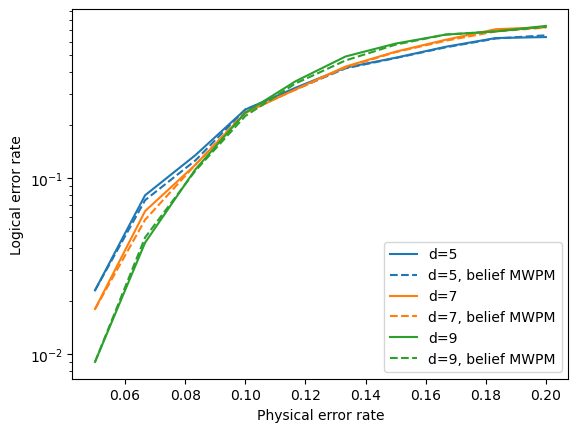

In [121]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure()

for i in range(len(d_list)):
    d = d_list[i]
    lers = [x for x in log_errors_MWPM_arr[i]]
    lers_belief = [x for x in log_errors_belief_arr[i]]
    line, = plt.plot(p_list, lers, label=f"d={d}")
    line_color = line.get_color()
    plt.plot(p_list, lers_belief, "--", label=f"d={d}, belief MWPM", color=line_color)
plt.yscale("log")
plt.xlabel("Physical error rate")
plt.ylabel("Logical error rate")
plt.legend(loc=0);
plt.show()

### BP + MWPM from arxiv:2306.17142v1

In [10]:
# not sure how to implement the cutoff from BP that is in LDPC package
from ldpc import BpDecoder
from pymatching import Matching


def BP_MWPM(syndrome, H, L, error_priors, max_iter, t, dem = None):
    print(H.shape)
    bp = BpDecoder(
                H,
                error_channel= error_priors,
                bp_method = 'product_sum',
                max_iter = max_iter,
                schedule = 'serial',
    )

    bp.decode(syndrome)
    llrs = bp.log_prob_ratios
    p_post = 1/(1+np.exp(llrs))

    error_p = (p_post > t).astype(np.uint8)
    syndrome_bp = H@error_p % 2
    syndrome_p = np.logical_xor(syndrome,syndrome_bp).astype(np.uint8)

    if not np.any(syndrome_p):
        total_correction = error_p
    else:
        matching = Matching(H) if dem is None else Matching.from_detector_error_model(dem)
        correction = matching.decode(syndrome_p)
        total_correction = np.logical_xor(error_p, correction).astype(np.uint8)
    return total_correction

p = 0.1
num_shots = 10
for _ in range(num_shots): 
    noise = np.random.binomial(1,p,Hx.shape[1])
    print(f"Noise: {noise}")
    syndrome = Hx@noise % 2

    total_correction = BP_MWPM(syndrome, Hx, Lx, p*np.ones(Hx.shape[1]), max_iter=7, t=0.5)
    print(f"Total correction: {total_correction}")
    residual = np.logical_xor(noise, total_correction)
    print(f"Predicted flip from BP + MWPM: {Lx@residual % 2}") 
    



NameError: name 'Hx' is not defined

In [ ]:
num_shots = 10000
max_iter = 30
t = 0.9
d_list = [5,7,9,13]
p_list = np.linspace(0.05,0.13,10)

log_errors_MWPM_arr = []
log_errors_BP_MWPM_arr = []

for d in d_list:
    Hx,Hz,Lx,Lz = get_parity_toric(d)
    log_error_MWPM_p = []
    log_error_BP_MWPM_p = []
    for p in p_list:
        log_error_MWPM = 0
        log_error_BP_MWPM = 0
        for _ in range(num_shots):
            noise = np.random.binomial(1,p,Hx.shape[1])
            syndrome = Hx@noise % 2

            matching = Matching(Hx)
            log_error_MWPM += get_log_error(matching, syndrome, Lx, noise)/num_shots
            bp_matching = BP_MWPM(syndrome, Hx, Lx, float(p), max_iter, t)
            log_error_BP_MWPM += (not np.array_equal(Lx@bp_matching % 2, Lx@noise % 2))/num_shots
        log_error_BP_MWPM_p += [log_error_BP_MWPM]
        log_error_MWPM_p += [log_error_MWPM]
    log_errors_MWPM_arr.append(log_error_MWPM_p)
    log_errors_BP_MWPM_arr.append(log_error_BP_MWPM_p)
            
print(f"Log errors for MWPM: {log_errors_MWPM_arr}")
print(f"Log errors for belief MWPM: {log_errors_BP_MWPM_arr}")           
            

Log errors for MWPM: [[0.03169999999999988, 0.052100000000000465, 0.08000000000000126, 0.11880000000000238, 0.15649999999999908, 0.19689999999999463, 0.24469999999998937, 0.29569999999998375, 0.3535999999999774, 0.3867999999999737], [0.017099999999999952, 0.033199999999999924, 0.06250000000000076, 0.09400000000000167, 0.13380000000000158, 0.1927999999999951, 0.2489999999999889, 0.31489999999998164, 0.3696999999999756, 0.4313999999999688], [0.009499999999999998, 0.02049999999999993, 0.042700000000000196, 0.07850000000000122, 0.12570000000000248, 0.18379999999999608, 0.2616999999999875, 0.32659999999998035, 0.3952999999999728, 0.46479999999996513], [0.0021000000000000003, 0.007600000000000007, 0.02259999999999992, 0.04830000000000036, 0.10270000000000191, 0.16479999999999817, 0.2618999999999875, 0.35099999999997766, 0.447799999999967, 0.529299999999958]]
Log errors for belief MWPM: [[0.03159999999999988, 0.052100000000000465, 0.08000000000000126, 0.11880000000000238, 0.15649999999999908,

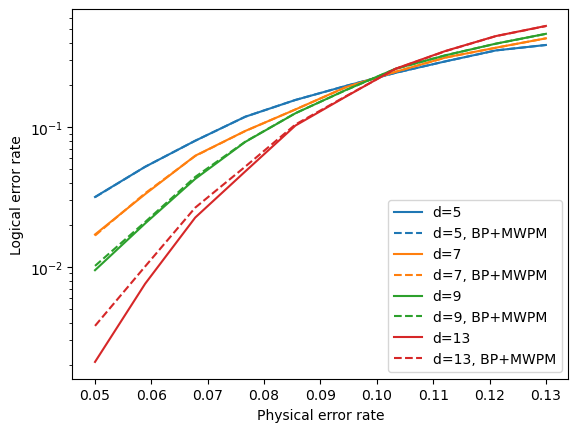

In [109]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure()

for i in range(len(d_list)):
    d = d_list[i]
    lers = [x for x in log_errors_MWPM_arr[i]]
    lers_belief = [x for x in log_errors_BP_MWPM_arr[i]]
    line, = plt.plot(p_list, lers, label=f"d={d}")
    line_color = line.get_color()
    plt.plot(p_list, lers_belief, "--", label=f"d={d}, BP+MWPM", color=line_color)
plt.yscale("log")
plt.xlabel("Physical error rate")
plt.ylabel("Logical error rate")
plt.legend(loc=0);
plt.show()

### BP + MWPM at Circuit Level, noise model in paper

In [ ]:
import stim
from quits.decoder import detector_error_model_to_matrix

p = 0.1
d = 5
t = 0.5
max_iter = 7
num_shots = 100

def get_log_error_CL_BP_MWPM_SC(p,d,t,max_iter, memory_type, shots):
    circuit = stim.Circuit.generated(f"surface_code:rotated_memory_{memory_type}",rounds=d, distance=d,
                                    after_clifford_depolarization=p,
                                    before_round_data_depolarization=p,
                                    before_measure_flip_probability=p,
                                    after_reset_flip_probability=p) # noise model kinda like the paper I guess
    num_errors = 0

    for k in range(shots):
        dem = circuit.detector_error_model() # not sure whether I should be decomposing errors etc
        detector_error_matrix, observables_matrix,priors = detector_error_model_to_matrix(dem)
        # print(f"Detector error matrix: {detector_error_matrix.shape}, Observables matrix: {observables_matrix.shape}, Priors: {priors.shape}")
        sampler = circuit.compile_detector_sampler()
        detection_events, obs_flips = sampler.sample(shots=num_shots, separate_observables=True)
        total_correction = BP_MWPM(detection_events[k,:], detector_error_matrix, observables_matrix, priors, max_iter=max_iter, t=t, dem=dem)
        # print(f"dem length: {len(dem)}, total detectors: {dem.num_detectors}") # concerning the length is different, probably just the number of detectors unused or smth
        predicted_flip = observables_matrix@total_correction % 2
        num_errors += not np.array_equal(predicted_flip, obs_flips[k,:]) # shot 0
    return num_errors / shots


def get_log_error_CL_MWPM_SC(p,d,memory_type, shots):
    circuit = stim.Circuit.generated(f"surface_code:rotated_memory_{memory_type}",rounds=d, distance=d,
                                    after_clifford_depolarization=p,
                                    before_round_data_depolarization=p,
                                    before_measure_flip_probability=p,
                                    after_reset_flip_probability=p) # noise model kinda like the paper I guess
    dem = circuit.detector_error_model()
    matching = Matching.from_detector_error_model(dem)
    sampler = circuit.compile_detector_sampler()
    syndrome, obs_flips = sampler.sample(shots=shots, separate_observables=True)
    predictions = matching.decode_batch(syndrome)
    return np.sum(np.array(obs_flips) != np.array(predictions))/shots

LER = get_log_error_CL_MWPM(p,d,memory_type="z", shots=num_shots)


0.53


In [ ]:
num_shots = 1000
max_iter = 30
t = 0.9
d_list = [5,7,9,13]
p_list = np.linspace(0.005,0.013,10)

LER_MWPM_arr = []
LER_BP_MWPM_arr = []

for d in d_list:
    log_error_MWPM_p = []
    log_error_BP_MWPM_p = []
    for p in p_list:
        log_error_BP_MWPM_p += [get_log_error_CL_BP_MWPM_SC(p,d,t,max_iter, memory_type="z", shots=num_shots)]
        log_error_MWPM_p += [get_log_error_CL_MWPM_SC(p,d,memory_type="z", shots=num_shots)]
    LER_MWPM_arr.append(log_error_MWPM_p)
    LER_BP_MWPM_arr.append(log_error_BP_MWPM_p)
            
print(f"Log errors for MWPM: {LER_MWPM_arr}")
print(f"Log errors for belief MWPM: {LER_BP_MWPM_arr}")   
    

(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120, 1677)
(120

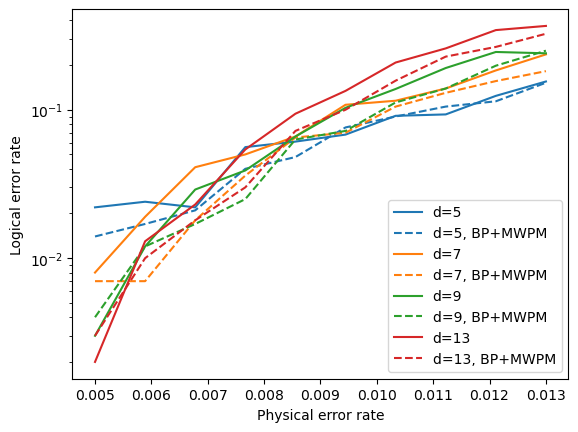

In [143]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure()

for i in range(len(d_list)):
    d = d_list[i]
    lers = [x for x in LER_MWPM_arr[i]]
    lers_bp_mwpm = [x for x in LER_BP_MWPM_arr[i]]
    line, = plt.plot(p_list, lers, label=f"d={d}")
    line_color = line.get_color()
    plt.plot(p_list, lers_bp_mwpm, "--", label=f"d={d}, BP+MWPM", color=line_color)
plt.yscale("log")
plt.xlabel("Physical error rate")
plt.ylabel("Logical error rate")
plt.legend(loc=0);
plt.show()

In [9]:
import pickle
import pandas as pd
import numpy as np

H = np.array(pd.read_pickle("/Users/ariannameinking/Documents/Brown_Research/realtime_decoding_qldpc/ordered_cx_72-12-6.pkl"))
print(H)

[[ 1 42 39 48 18  2]
 [ 2 43 40 49 19  3]
 [ 3 44 41 50 20  4]
 [ 4 45 36 51 21  5]
 [ 5 46 37 52 22  0]
 [ 0 47 38 53 23  1]
 [ 7 48 45 54 24  8]
 [ 8 49 46 55 25  9]
 [ 9 50 47 56 26 10]
 [10 51 42 57 27 11]
 [11 52 43 58 28  6]
 [ 6 53 44 59 29  7]
 [13 54 51 60 30 14]
 [14 55 52 61 31 15]
 [15 56 53 62 32 16]
 [16 57 48 63 33 17]
 [17 58 49 64 34 12]
 [12 59 50 65 35 13]
 [19 60 57 66  0 20]
 [20 61 58 67  1 21]
 [21 62 59 68  2 22]
 [22 63 54 69  3 23]
 [23 64 55 70  4 18]
 [18 65 56 71  5 19]
 [25 66 63 36  6 26]
 [26 67 64 37  7 27]
 [27 68 65 38  8 28]
 [28 69 60 39  9 29]
 [29 70 61 40 10 24]
 [24 71 62 41 11 25]
 [31 36 69 42 12 32]
 [32 37 70 43 13 33]
 [33 38 71 44 14 34]
 [34 39 66 45 15 35]
 [35 40 67 46 16 30]
 [30 41 68 47 17 31]
 [54 40  3 30 24 41]
 [55 41  4 31 25 36]
 [56 36  5 32 26 37]
 [57 37  0 33 27 38]
 [58 38  1 34 28 39]
 [59 39  2 35 29 40]
 [60 46  9  0 30 47]
 [61 47 10  1 31 42]
 [62 42 11  2 32 43]
 [63 43  6  3 33 44]
 [64 44  7  4 34 45]
 [65 45  8  5

In [1]:
from quits.qldpc_code import BbCode, BpcCode, HgpCode
from quits.decoder import sliding_window_bposd_circuit_mem
from quits.simulation import get_stim_mem_result
from quits import ErrorModel
import numpy as np 


# multiple ways to get BB codes, not sure what they mean
p = 0.003

bb = BbCode(
    l=15,
    m=3,
    A_x_pows=[9],
    A_y_pows=[1, 2],
    B_x_pows=[2, 7],
    B_y_pows=[0],
)

error_model = ErrorModel(
    idle_error=p,
    sqgate_error=p,
    tqgate_error=p,
    spam_error=p,
)
custom_circuit = bb.build_circuit(strategy="custom", num_rounds=1, basis="Z", error_model=error_model)
print("BB custom depth:", bb.depth)
print("Circuit instructions:", len(custom_circuit))

BB custom depth: 7
Circuit instructions: 144


In [35]:
from quits.qldpc_code import BbCode, BpcCode, HgpCode
from quits.decoder import sliding_window_bposd_circuit_mem,detector_error_model_to_matrix
from quits.simulation import get_stim_mem_result
from quits import ErrorModel


def BP_MWPM(syndrome, H, L, error_priors, max_iter, t, dem = None):
    print(H.shape)
    bp = BpDecoder(
                H,
                error_channel= error_priors,
                bp_method = 'product_sum',
                max_iter = max_iter,
                schedule = 'serial',
    )

    bp.decode(syndrome)
    llrs = bp.log_prob_ratios
    p_post = 1/(1+np.exp(llrs))

    error_p = (p_post > t).astype(np.uint8)
    syndrome_bp = H@error_p % 2
    syndrome_p = np.logical_xor(syndrome,syndrome_bp).astype(np.uint8)

    if not np.any(syndrome_p):
        total_correction = error_p
    else:
        matching = Matching(H) if dem is None else Matching.from_detector_error_model(dem)
        correction = matching.decode(syndrome_p)
        total_correction = np.logical_xor(error_p, correction).astype(np.uint8)
    return total_correction

def get_log_error_CL_BP_MWPM(circuit,t,max_iter,shots):
    num_errors = 0

    for k in range(shots):
        dem = circuit.detector_error_model() # not sure whether I should be decomposing errors etc
        dem_decomposed = circuit.detector_error_model(decompose_errors=True,ignore_decomposition_failures=True)
        detector_error_matrix, observables_matrix,priors = detector_error_model_to_matrix(dem)
        # print(f"Detector error matrix: {detector_error_matrix.shape}, Observables matrix: {observables_matrix.shape}, Priors: {priors.shape}")
        sampler = circuit.compile_detector_sampler()
        detection_events, obs_flips = sampler.sample(shots=num_shots, separate_observables=True)
        total_correction = BP_MWPM(detection_events[k,:], detector_error_matrix, observables_matrix, priors, max_iter=max_iter, t=t, dem=dem_decomposed)
        # print(f"dem length: {len(dem)}, total detectors: {dem.num_detectors}") # concerning the length is different, probably just the number of detectors unused or smth
        predicted_flip = observables_matrix@total_correction % 2
        num_errors += not np.array_equal(predicted_flip, obs_flips[k,:]) # shot 0
        
    return num_errors / shots


def get_log_error_CL_MWPM(circuit, shots):
    dem = circuit.detector_error_model()
    matching = Matching.from_detector_error_model(dem)
    sampler = circuit.compile_detector_sampler()
    syndrome, obs_flips = sampler.sample(shots=shots, separate_observables=True)
    predictions = matching.decode_batch(syndrome)
    return np.sum(np.array(obs_flips) != np.array(predictions))/shots

In [ ]:
num_shots = 1000
max_iter = 30
t = 0.9
# d_list = [5,7,9,13]
memory_type = "Z"

# I am going through [[72,12,6]], [[90,8,10]], [[144,12,12]] 

# try the 144 code from fig 3 tour de gross

l_list = [6,15,12] # from nature paper
m_list = [6,3,6]
A_x_list = [[3], [9], [3]] 
A_y_list = [[1, 2], [1, 2], [1, 2]]
B_x_list = [[1, 2], [2, 7], [1, 2]]
B_y_list = [[3], [0], [3]]
d_list = [6,10,12]
p_list = np.linspace(0.005,0.013,10)

error_model = ErrorModel(
    idle_error=p,
    sqgate_error=p,
    tqgate_error=p,
    spam_error=p,
)

LER_MWPM_arr = []
LER_BP_MWPM_arr = []

circuits = []
for l,m,A_x,A_y,B_x,B_y,d in zip(l_list, m_list, A_x_list, A_y_list, B_x_list, B_y_list, d_list):
    bb = BbCode(
    l=l,
    m=m,
    A_x_pows=A_x,
    A_y_pows=A_y,
    B_x_pows=B_x,
    B_y_pows=B_y,
    )
    custom_circuit = bb.build_circuit(strategy="custom", num_rounds=d, basis=memory_type, error_model=error_model)
    circuits += [custom_circuit]

for i,d in enumerate(d_list):
    log_error_MWPM_p = []
    log_error_BP_MWPM_p = []
    for p in p_list:
        circuit = circuits[i]
        log_error_BP_MWPM_p += [get_log_error_CL_BP_MWPM(circuit, t,max_iter, shots=num_shots)]
        log_error_MWPM_p += [get_log_error_CL_MWPM_SC(p,d,memory_type=memory_type, shots=num_shots)]
    LER_MWPM_arr.append(log_error_MWPM_p)
    LER_BP_MWPM_arr.append(log_error_BP_MWPM_p)
            
# getting an error based on checks ... hyperedges / degree 3 checks are I think causing the problem.
# decomposing errors causes other flags ... can't get graphlike decomposition which is sad
# I do get the same error when just looking at Hx or Hz of the code directly no circuit level



(72, 144)


ValueError: `check_matrix` must contain at most two ones per column, but column 0 has 3 ones.